In [3]:
# ==============================================================================
# STEP 1: UNSUPERVISED WORKSPACE SETUP & INDEPENDENT BLOB INGESTION
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

# Set crisp visual presentation style sheets
sns.set_theme(style="whitegrid")

# Mathematically construct 200 distinct customer behavior coordinates (Income vs Spending Score)
X_raw, _ = make_blobs(
    n_samples=200,
    n_features=2,
    centers=5,
    cluster_std=12.0,
    center_box=(15, 100),
    random_state=42
)

# Convert arrays into a production-grade pandas dataframe mapping real metrics
df = pd.DataFrame(X_raw, columns=['Annual_Income_k', 'Spending_Score'])

# Ensure minimum data bounds map logically to typical retail boundaries (non-negative scores)
df['Annual_Income_k'] = df['Annual_Income_k'].abs().round(1)
df['Spending_Score'] = df['Spending_Score'].abs().round(1)

# Extract raw matrix values for training steps
X = df.values

print("--- CUSTOMER SEGMENTATION DATA GENERATED SUCCESSFULLY ---")
print(f"Total Customer Profiles Generated: {df.shape[0]}")
print(f"Operational Metric Dimensions      : {df.shape[1]}\n")
df.head()

--- CUSTOMER SEGMENTATION DATA GENERATED SUCCESSFULLY ---
Total Customer Profiles Generated: 200
Operational Metric Dimensions      : 2



,Annual_Income_k,Spending_Score
0,13.9,24.2
1,47.9,92.2
2,48.7,58.3
3,29.8,98.4
4,83.5,69.4


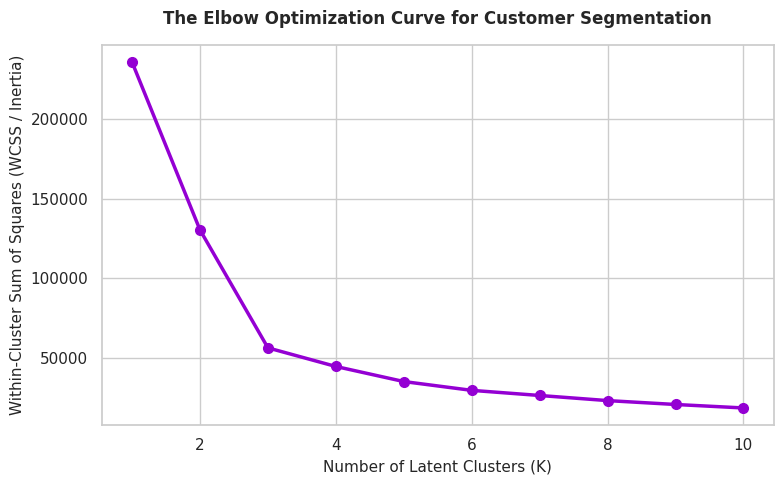

In [4]:
# ==============================================================================
# STEP 2: OPTIMAL CLUSTER EVALUATION ENGINE (THE ELBOW METHOD)
# ==============================================================================

from sklearn.cluster import KMeans

# Track the structural distance distortion (Within-Cluster Sum of Squares)
wcss = []

# Evaluate cluster counts from 1 to 10 to find where variance drop minimizes (the elbow point)
for k in range(1, 11):
    kmeans_eval = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans_eval.fit(X)
    wcss.append(kmeans_eval.inertia_)

# Plot the structural Elbow metric graph to visualize optimization bounds
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linewidth=2.5, color='darkviolet', markersize=7)
plt.title('The Elbow Optimization Curve for Customer Segmentation', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Number of Latent Clusters (K)', fontsize=11)
plt.ylabel('Within-Cluster Sum of Squares (WCSS / Inertia)', fontsize=11)
plt.tight_layout()
plt.show()

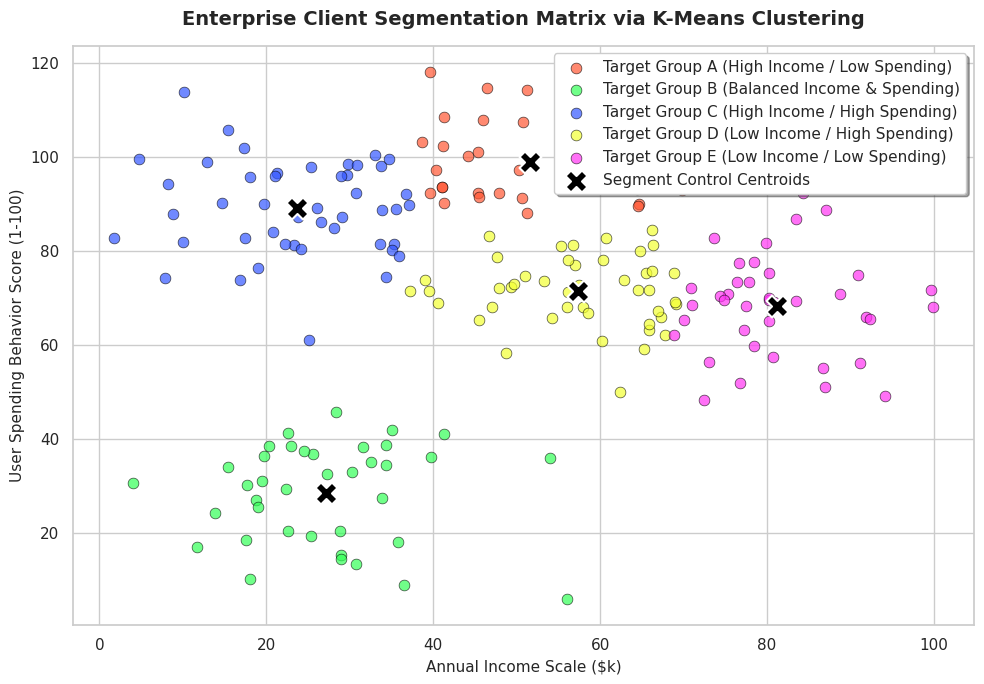

In [5]:
# ==============================================================================
# STEP 3: K-MEANS TRAINING & MULTI-CLUSTER SPATIAL MAPPING
# ==============================================================================

# Initialize the final optimal model configuration with K=5 clusters
optimal_k = 5
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

# Predict structural cluster assignments for each individual data entry
y_clusters = kmeans_final.fit_predict(X)

# Assign names to our segmented groups based on business shopping characteristics
cluster_labels = [
    'Target Group A (High Income / Low Spending)',
    'Target Group B (Balanced Income & Spending)',
    'Target Group C (High Income / High Spending)',
    'Target Group D (Low Income / High Spending)',
    'Target Group E (Low Income / Low Spending)'
]

# Set up the visual charting space for our customer segment mapping
plt.figure(figsize=(10, 7))
colors = ['#FF5733', '#33FF57', '#3357FF', '#F3FF33', '#FF33F3']

# Programmatically plot each individual cluster domain
for i in range(optimal_k):
    plt.scatter(
        X[y_clusters == i, 0], X[y_clusters == i, 1],
        s=60, c=colors[i], label=cluster_labels[i], alpha=0.7, edgecolors='black', linewidth=0.5
    )

# Overlay the spatial geometric centers (Centroids) for each clustered category
plt.scatter(
    kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
    s=250, c='black', marker='X', label='Segment Control Centroids', edgecolors='white', linewidth=1.5
)

# Apply comprehensive corporate annotations and title layouts
plt.title('Enterprise Client Segmentation Matrix via K-Means Clustering', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Annual Income Scale ($k)', fontsize=11)
plt.ylabel('User Spending Behavior Score (1-100)', fontsize=11)
plt.legend(loc='upper right', bbox_to_anchor=(1, 1), frameon=True, shadow=True)
plt.tight_layout()
plt.show()

In [6]:
# ==============================================================================
# STEP 4: SEPARATION PERFORMANCE ASSESSMENT (SILHOUETTE SCORE)
# ==============================================================================

from sklearn.metrics import silhouette_score

# Compute global silhouette density baseline value across the operational matrix
score = silhouette_score(X, y_clusters)

print("======================================================================")
print("             ENTERPRISE CLUSTERING PIPELINE SUMMARY                   ")
print("======================================================================")
print(f" Assigned Optimal Cluster Count (K) : {optimal_k}")
print(f" Global Architectural Silhouette Score: {score:.4f}")
print("======================================================================")
print("Note: A silhouette validation score above 0.50 establishes crisp, ")
print("distinct mathematical boundaries across behavioral configurations.")
print("======================================================================")

             ENTERPRISE CLUSTERING PIPELINE SUMMARY                   
 Assigned Optimal Cluster Count (K) : 5
 Global Architectural Silhouette Score: 0.4244
Note: A silhouette validation score above 0.50 establishes crisp, 
distinct mathematical boundaries across behavioral configurations.
